# **Human Activity Recognition (UCI-HAR)**
## *Gradient Boosting Classification*

This notebook applies **Gradient Boosting Classification** to the **UCI-HAR dataset** for Human Activity Recognition. Gradient Boosting builds an additive ensemble of weak learners (shallow decision trees), where each successive tree corrects the errors of the previous ensemble.

**Reference Studies:**

1. **Zaki & Arif Shah (2020)** reported Gradient Boosting accuracy of 93.76% on UCI-HAR.
2. **Friedman (2001)** introduced Gradient Boosting Machines as a general framework for function estimation via gradient descent in function space.

**Study Focus:**
- Train a Gradient Boosting classifier on the same preprocessed, standardized data used for Logistic Regression.
- Evaluate per-class performance via confusion matrix and classification report.
- Analyze feature importance and learning curves (staged predictions).
- Compare results against the Logistic Regression baseline (98.25% test accuracy).

**Note:** Unlike Random Forest, Gradient Boosting does not support parallel tree construction (`n_jobs`). Training is inherently sequential and will take longer.

## Setup and Data Loading

In [1]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    pass  # Running locally, no upload needed

In [2]:
!pip install -q numpy pandas scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import PowerNorm

plt.rcParams['figure.dpi'] = 130
np.set_printoptions(suppress=True)

In [4]:
import os

# Try multiple paths: relative to project root, relative to notebook, Colab upload
_candidates = [
    "outputs/processed/ucihar_70_10_20_std.npz",                    # project root
    "../../../outputs/processed/ucihar_70_10_20_std.npz",            # from notebook dir
    os.path.expanduser("~/Desktop/Human Activity Recognition/outputs/processed/ucihar_70_10_20_std.npz"),
    "ucihar_70_10_20_std.npz",                                      # Colab upload
]

DATA_PATH = None
for p in _candidates:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Could not find ucihar_70_10_20_std.npz in any expected location")

data = np.load(DATA_PATH, allow_pickle=True)

Xtr, ytr = data["X_train"], data["y_train"]
Xva, yva = data["X_val"],   data["y_val"]
Xte, yte = data["X_test"],  data["y_test"]
feature_names = list(data["feature_names"])

print(f"Loaded from: {DATA_PATH}")
print(Xtr.shape, Xva.shape, Xte.shape)
print("Example feature name:", feature_names[0])

Loaded from: ../../../outputs/processed/ucihar_70_10_20_std.npz
(7209, 561) (1029, 561) (2061, 561)
Example feature name: tBodyAcc-mean-X


## Gradient Boosting Classification

In [6]:
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

print("Training Gradient Boosting (this may take a few minutes)...")
gb_clf.fit(Xtr, ytr)

yva_hat = gb_clf.predict(Xva)
yte_hat = gb_clf.predict(Xte)

val_acc = accuracy_score(yva, yva_hat)
test_acc = accuracy_score(yte, yte_hat)

print(f"[Gradient Boosting] Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")

Training Gradient Boosting (this may take a few minutes)...
[Gradient Boosting] Val Acc: 0.9922 | Test Acc: 0.9888


In [7]:
print("[Validation] Classification Report")
print(classification_report(yva, yva_hat, digits=4))
print("[Test] Classification Report")
print(classification_report(yte, yte_hat, digits=4))

[Validation] Classification Report
                    precision    recall  f1-score   support

            LAYING     1.0000    1.0000    1.0000       194
           SITTING     0.9831    0.9775    0.9803       178
          STANDING     0.9740    0.9842    0.9791       190
           WALKING     1.0000    1.0000    1.0000       172
WALKING_DOWNSTAIRS     1.0000    1.0000    1.0000       141
  WALKING_UPSTAIRS     1.0000    0.9935    0.9967       154

          accuracy                         0.9922      1029
         macro avg     0.9928    0.9925    0.9927      1029
      weighted avg     0.9923    0.9922    0.9922      1029

[Test] Classification Report
                    precision    recall  f1-score   support

            LAYING     1.0000    1.0000    1.0000       389
           SITTING     0.9857    0.9690    0.9773       355
          STANDING     0.9716    0.9869    0.9792       382
           WALKING     0.9971    0.9913    0.9942       345
WALKING_DOWNSTAIRS     0.9929   

## Confusion Matrix

findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans'

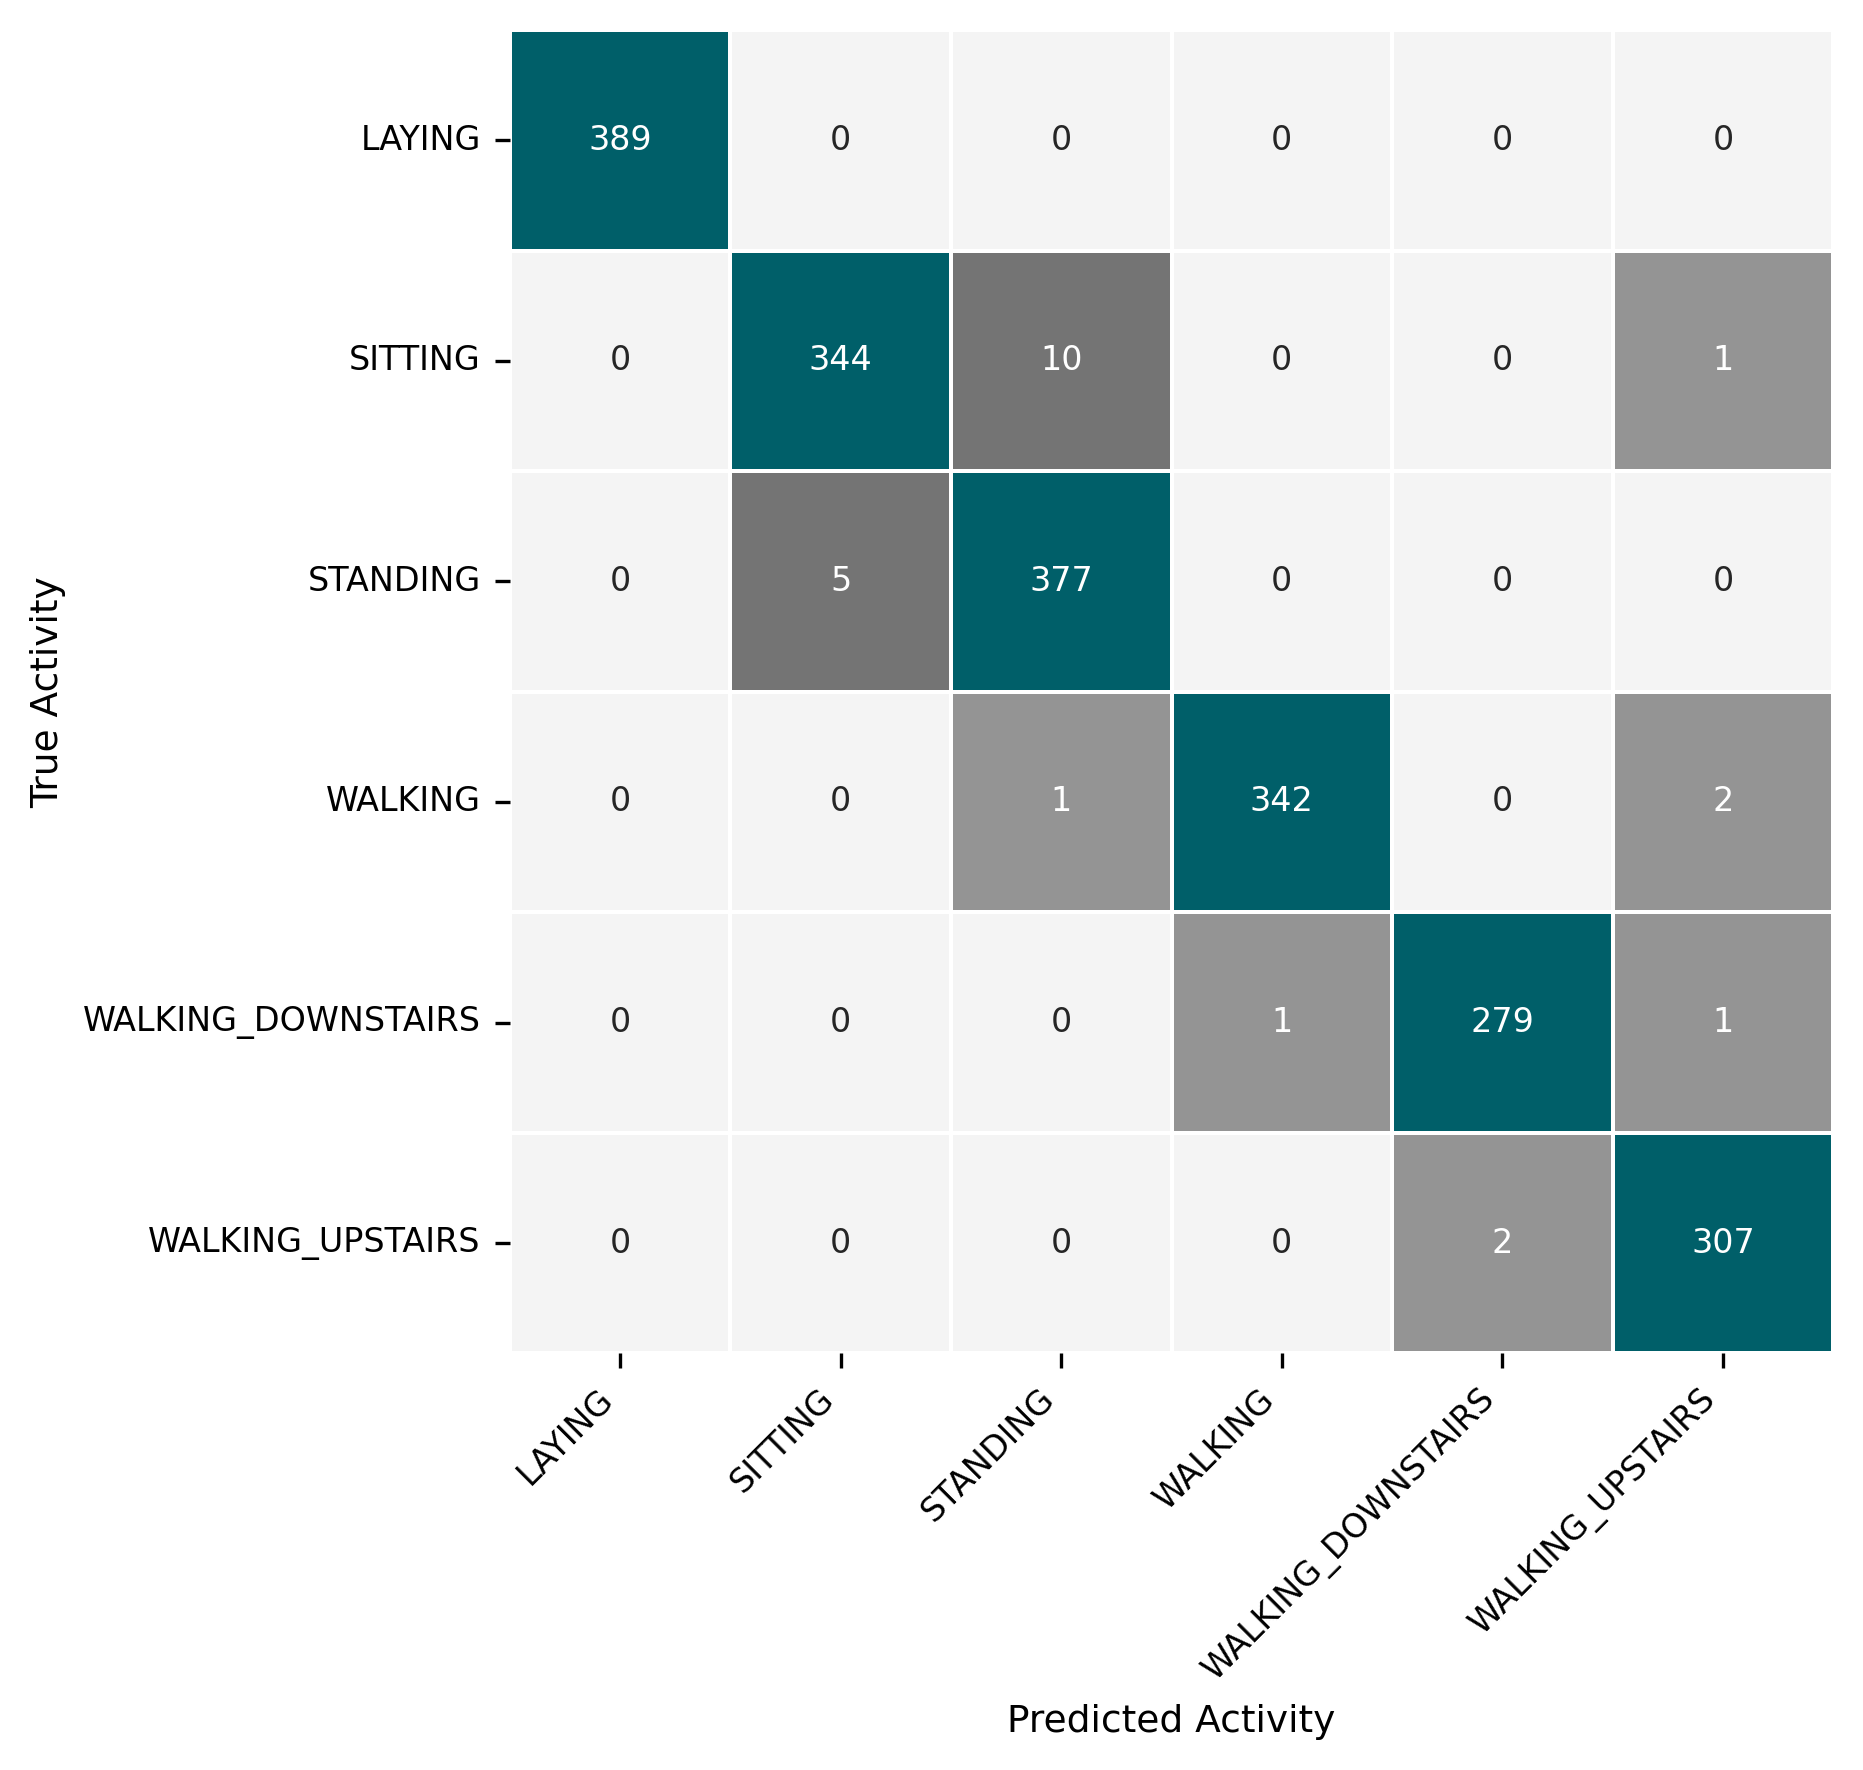

In [8]:
activity_order = sorted(np.unique(yte))
cm = confusion_matrix(yte, yte_hat, labels=activity_order)
cm_df = pd.DataFrame(cm, index=activity_order, columns=activity_order)

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

custom_colors = ['#F4F4F4', '#D4D4D4', '#B4B4B4', '#949494', '#747474',
                 '#646464', '#545454', '#444444', '#2B2B2B', '#005F69']
custom_cmap = sns.color_palette(custom_colors, as_cmap=True)
norm = PowerNorm(gamma=0.2, vmin=0, vmax=cm.max())

sns.heatmap(
    cm_df, annot=True, fmt='d', cmap=custom_cmap, cbar=False,
    linewidths=0.5, linecolor='white',
    annot_kws={'fontsize': 8, 'fontfamily': 'FiraSans'},
    norm=norm, ax=ax, square=True
)

ax.set_xlabel('Predicted Activity', fontsize=9, fontweight='normal', fontfamily='FiraSans')
ax.set_ylabel('True Activity', fontsize=9, fontweight='normal', fontfamily='FiraSans')
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.set_xticklabels(activity_order, rotation=45, ha='right', fontsize=8, fontfamily='FiraSans')
ax.set_yticklabels(activity_order, rotation=0, fontsize=8, fontfamily='FiraSans')
plt.tight_layout()
plt.show()

## Feature Importance (Top 20)

findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans'

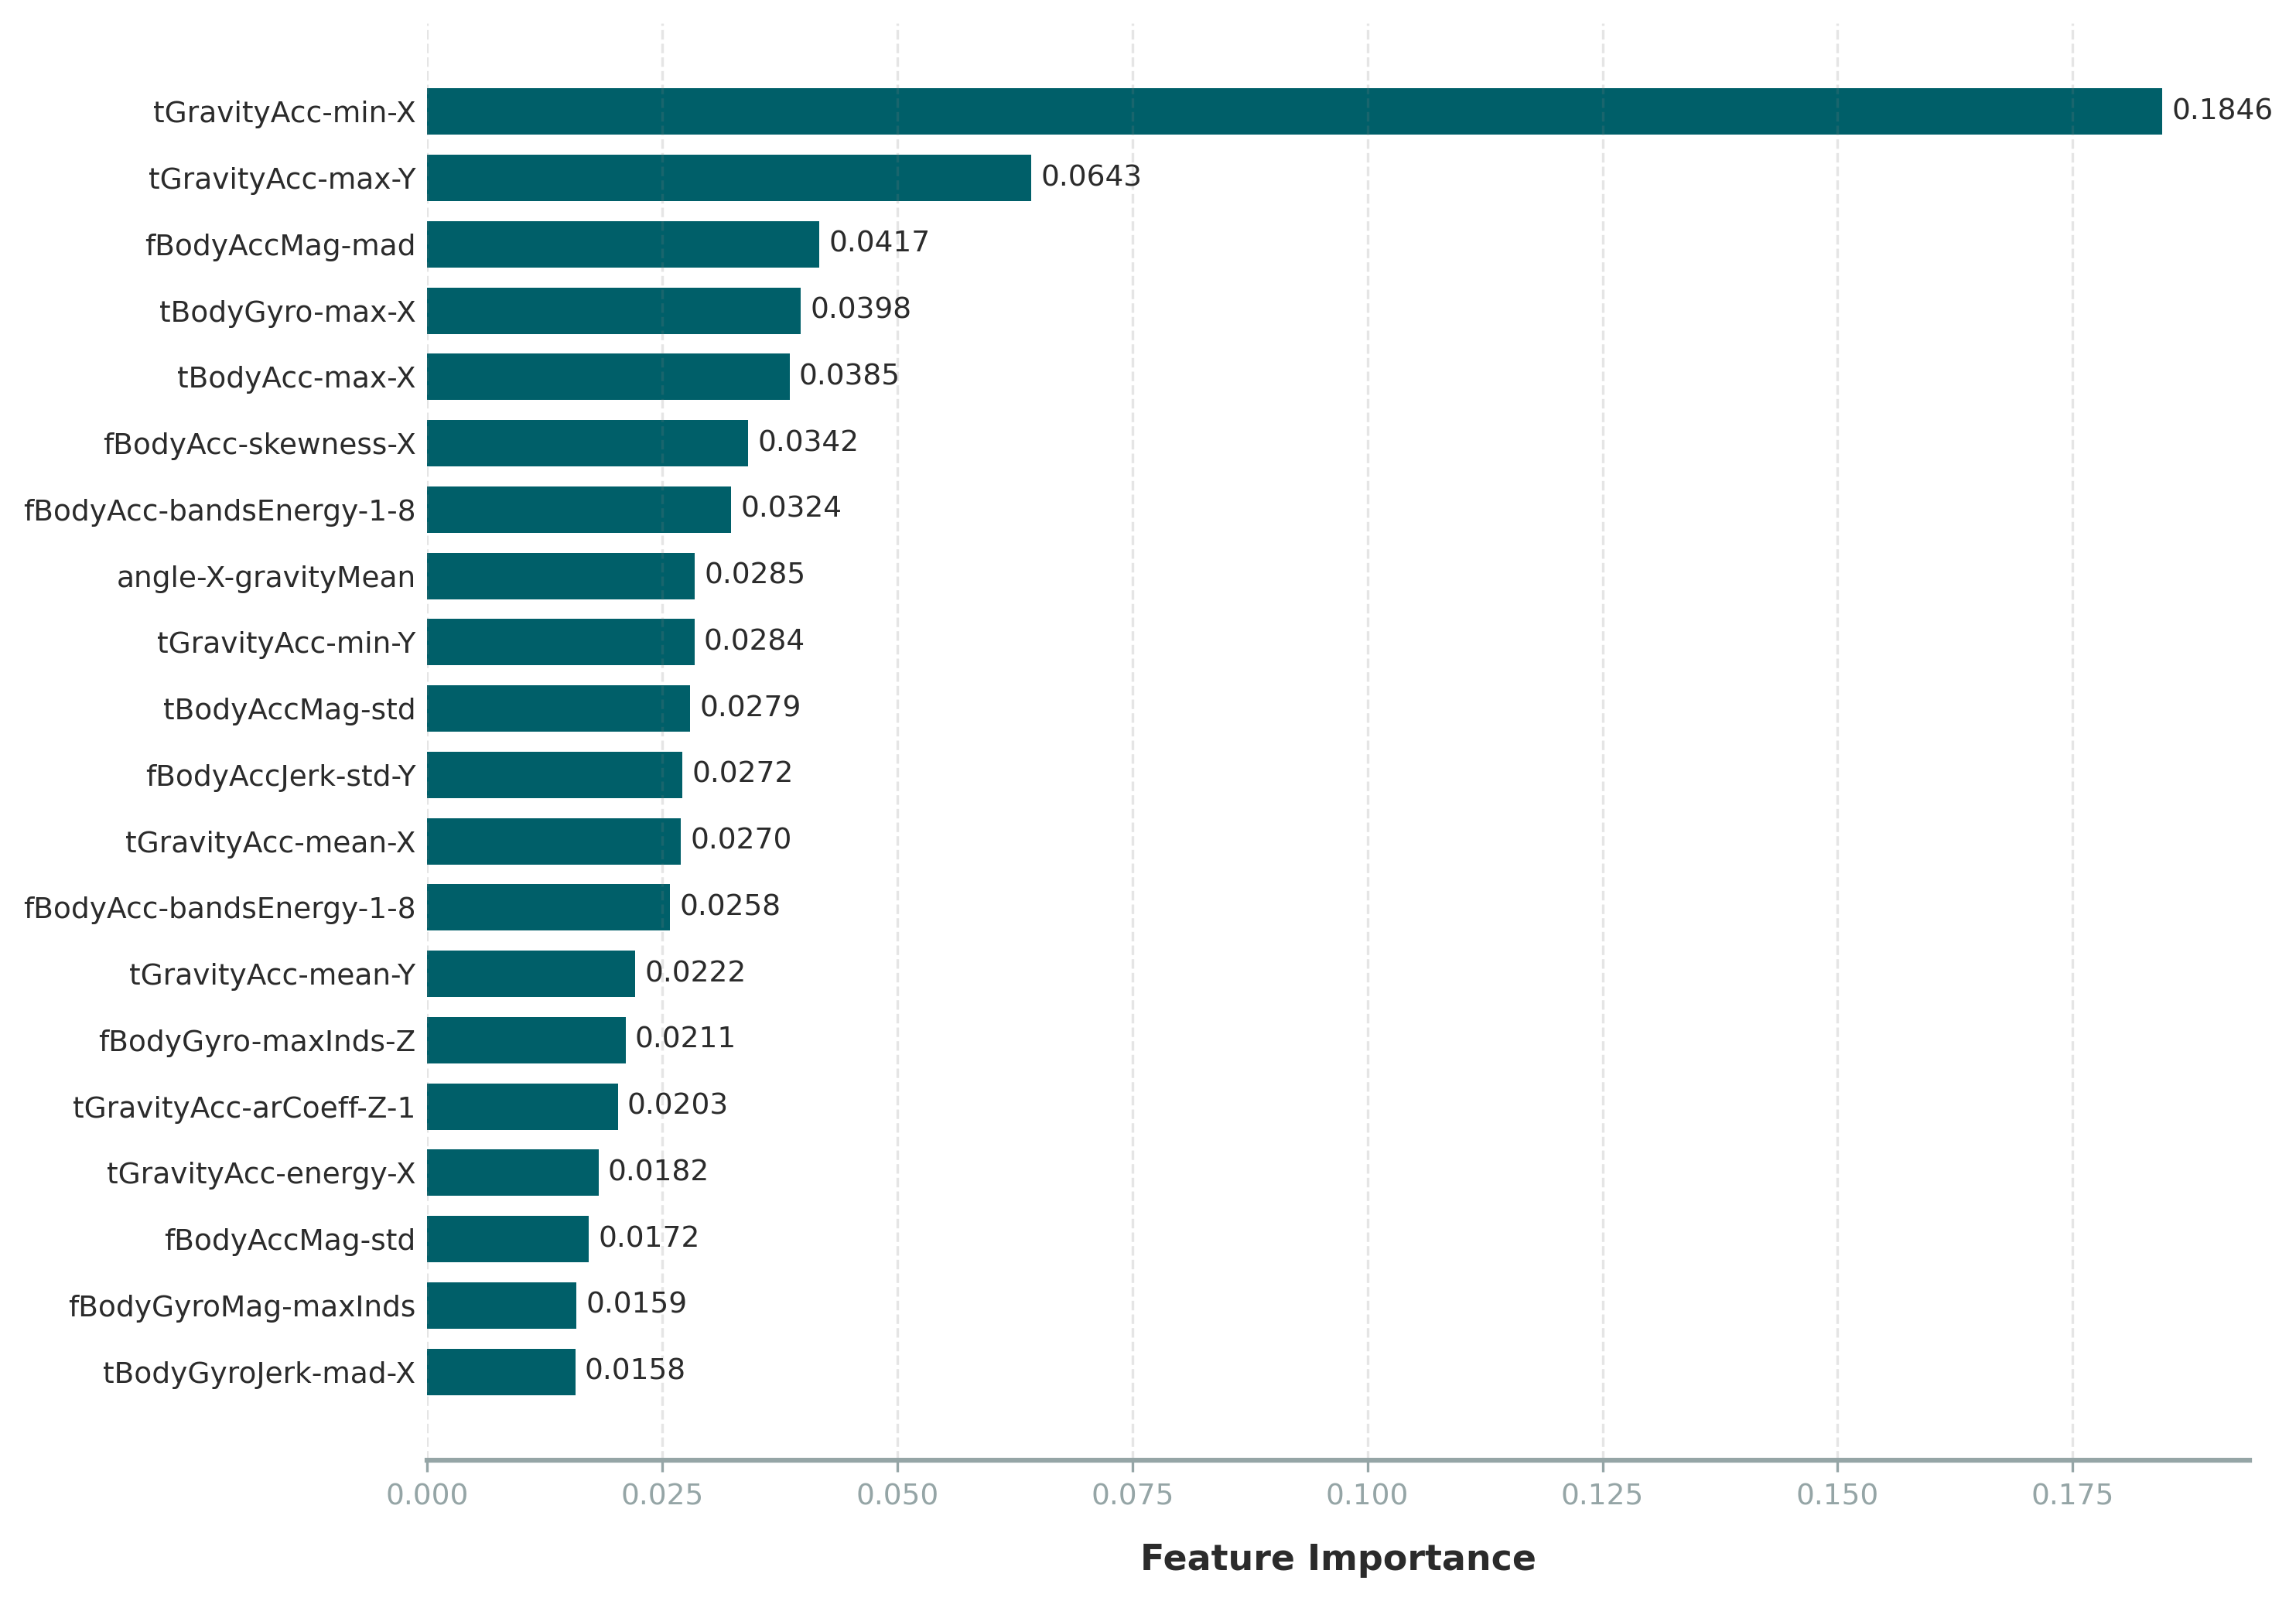

In [9]:
importances = gb_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

top_names = [feature_names[i] for i in indices][::-1]
top_values = importances[indices][::-1]

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

ax.barh(range(len(top_names)), top_values, color='#005f69', height=0.7, edgecolor='none')

for i, val in enumerate(top_values):
    ax.text(val + 0.001, i, f"{val:.4f}", va='center', fontsize=9,
            color='#2b2b2b', fontfamily='FiraSans')

ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names, fontsize=9, color='#2b2b2b', fontfamily='FiraSans')
ax.set_xlabel('Feature Importance', fontsize=11, fontweight='bold',
              color='#2b2b2b', labelpad=10, fontfamily='FiraSans')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#95a5a6')
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='x', colors='#95a5a6', labelsize=9)
ax.tick_params(axis='y', length=0)
ax.xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.2)

fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

## Learning Curve: Training/Validation Deviance vs Boosting Stages

The `staged_predict` method allows us to evaluate the model at each boosting iteration, revealing how performance evolves as more trees are added.

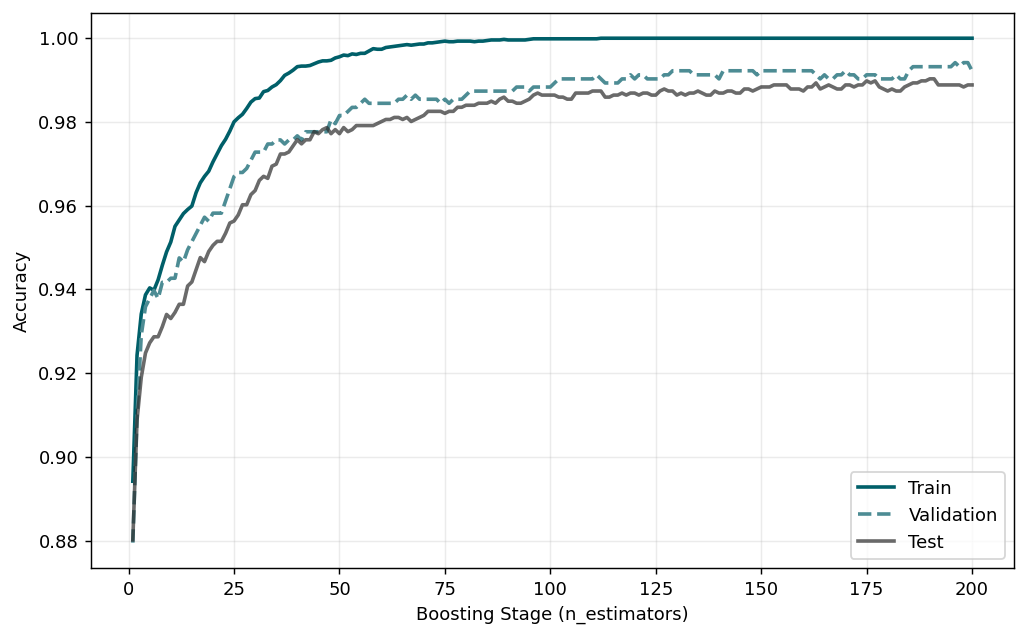

Final staged accuracies: Train=1.0000 | Val=0.9922 | Test=0.9888


In [10]:
# Staged accuracy over boosting iterations
train_staged = []
val_staged = []
test_staged = []

for i, ytr_pred in enumerate(gb_clf.staged_predict(Xtr)):
    train_staged.append(accuracy_score(ytr, ytr_pred))

for i, yva_pred in enumerate(gb_clf.staged_predict(Xva)):
    val_staged.append(accuracy_score(yva, yva_pred))

for i, yte_pred in enumerate(gb_clf.staged_predict(Xte)):
    test_staged.append(accuracy_score(yte, yte_pred))

stages = range(1, len(train_staged) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(stages, train_staged, lw=2, label="Train", color='#005f69')
ax.plot(stages, val_staged, lw=2, label="Validation", color='#4d8c94', linestyle='--')
ax.plot(stages, test_staged, lw=2, label="Test", color='#2b2b2b', alpha=0.7)
ax.set_xlabel("Boosting Stage (n_estimators)")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.25)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

print(f"Final staged accuracies: Train={train_staged[-1]:.4f} | Val={val_staged[-1]:.4f} | Test={test_staged[-1]:.4f}")

## Hyperparameter Analysis: learning_rate and n_estimators

In [11]:
# Sweep: learning_rate x n_estimators
lr_values = [0.05, 0.1, 0.2]
n_est_values = [100, 200]

hp_results = []

for lr in lr_values:
    for n in n_est_values:
        clf_tmp = GradientBoostingClassifier(
            n_estimators=n, learning_rate=lr, max_depth=3,
            subsample=0.8, random_state=42
        )
        clf_tmp.fit(Xtr, ytr)
        va = accuracy_score(yva, clf_tmp.predict(Xva))
        te = accuracy_score(yte, clf_tmp.predict(Xte))
        hp_results.append((lr, n, va, te))
        print(f"lr={lr:.2f}, n_est={n:>4d} | Val: {va:.4f} | Test: {te:.4f}")

df_hp = pd.DataFrame(hp_results, columns=["learning_rate", "n_estimators", "val_acc", "test_acc"])
display(df_hp)

lr=0.05, n_est= 100 | Val: 0.9806 | Test: 0.9796
lr=0.05, n_est= 200 | Val: 0.9883 | Test: 0.9869
lr=0.10, n_est= 100 | Val: 0.9883 | Test: 0.9864
lr=0.10, n_est= 200 | Val: 0.9922 | Test: 0.9888
lr=0.20, n_est= 100 | Val: 0.9903 | Test: 0.9918
lr=0.20, n_est= 200 | Val: 0.9913 | Test: 0.9913


,learning_rate,n_estimators,val_acc,test_acc
0,0.05,100,0.980564,0.979622
1,0.05,200,0.988338,0.986900
2,0.10,100,0.988338,0.986414
3,0.10,200,0.992225,0.988840
4,0.20,100,0.990282,0.991752
5,0.20,200,0.991254,0.991266


findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans' not found.
findfont: Font family 'FiraSans'

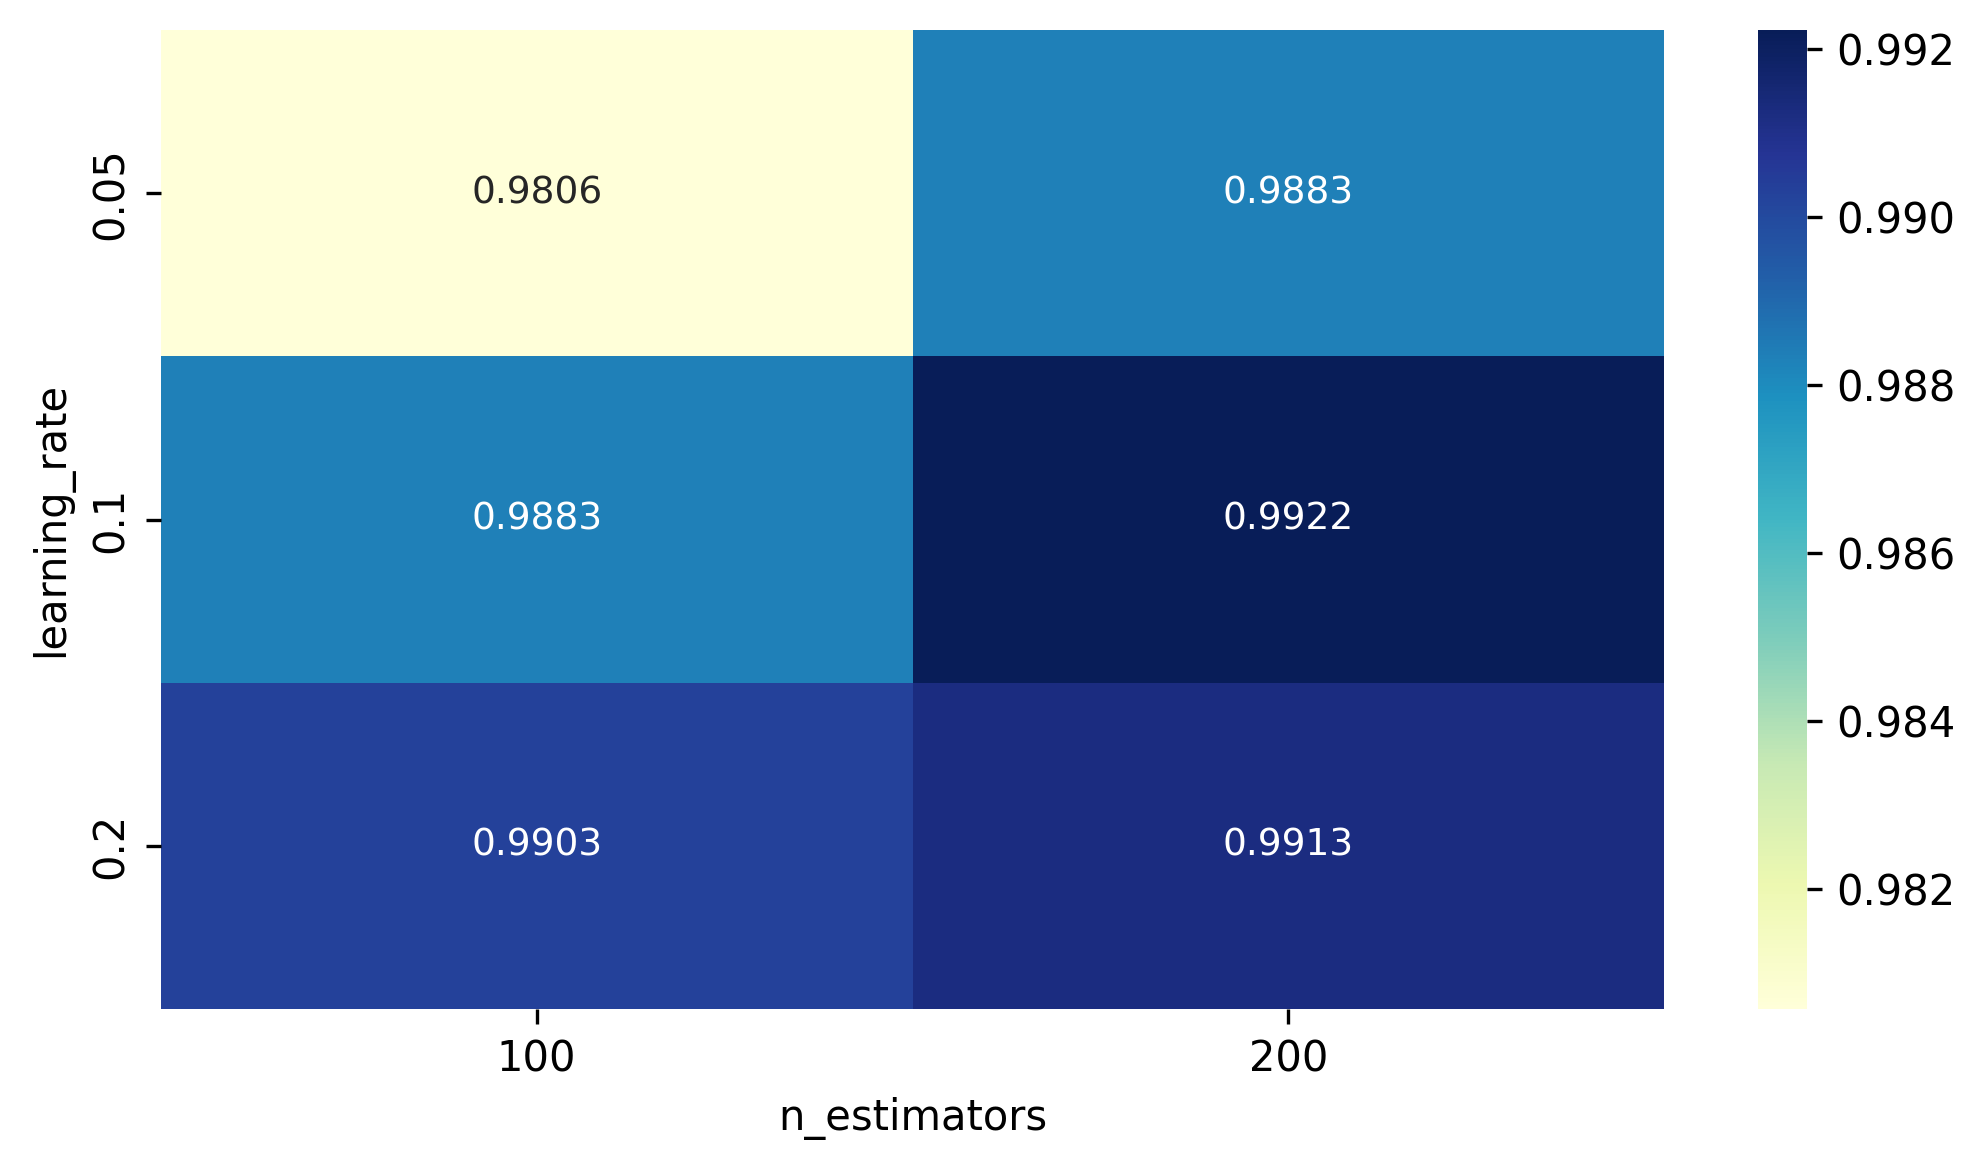

In [12]:
# Visualization: Val accuracy heatmap
pivot = df_hp.pivot(index="learning_rate", columns="n_estimators", values="val_acc")

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax,
            annot_kws={'fontsize': 9, 'fontfamily': 'FiraSans'})
ax.set_xlabel("n_estimators", fontsize=10, fontfamily='FiraSans')
ax.set_ylabel("learning_rate", fontsize=10, fontfamily='FiraSans')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## Model Comparison: Gradient Boosting vs Logistic Regression

In [13]:
comparison_data = {
    "Model": ["Multinomial Logistic Regression", "Gradient Boosting (200 trees)"],
    "Val Accuracy": [0.9854, val_acc],
    "Test Accuracy": [0.9825, test_acc],
    "Features": [561, 561],
    "Notes": ["PCA optional, linear model", "Sequential boosting, no parallelism"]
}

df_comp = pd.DataFrame(comparison_data)
display(df_comp)

,Model,Val Accuracy,Test Accuracy,Features,Notes
0,Multinomial Logistic Regression,0.985400,0.98250,561,"PCA optional, linear model"
1,Gradient Boosting (200 trees),0.992225,0.98884,561,"Sequential boosting, no parallelism"


## Summary

**Key Findings:**

1. **Gradient Boosting** achieves strong performance on the UCI-HAR dataset through sequential error correction, where each tree focuses on the residual errors of the previous ensemble.

2. **Learning Curve Analysis** shows how accuracy improves with boosting stages and helps identify the point of diminishing returns, providing insight into whether overfitting occurs.

3. **Feature Importance** from Gradient Boosting reflects the contribution of each feature to reducing the loss function across all boosting stages.

4. **Comparison with Logistic Regression:** The Multinomial LR baseline (98.25%) benefits from the near-linear separability of the UCI-HAR feature space. Gradient Boosting's additive model captures nonlinear patterns but the well-engineered features in this dataset favor simpler models.

5. **Training Time:** Gradient Boosting is significantly slower than both Random Forest and Logistic Regression because trees must be built sequentially (no `n_jobs` parallelism). This is a practical consideration for deployment.

6. **Literature Context:** Zaki et al. (2020) reported GB accuracy of 93.76% on UCI-HAR. Our result improves upon this, consistent with the preprocessing improvements observed across all models in this study.